# Pipeline for the anomaly detection on the SKAB using LSTM-Autoencoder

Details regarding the SKAB one can find in the [SKAB repository](https://github.com/waico/SKAB).

In [1]:
# libraries importing
import sys
import warnings

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

sys.path.append("..")
from core.LSTM_AE_pytorch import LSTM_AE
from core.metrics import chp_score
from core.utils import create_sequences, load_preprocess_skab, plot_results

warnings.filterwarnings("ignore", category=UserWarning)

## Data

In [2]:
Xy_traintest_list = load_preprocess_skab()

## Method

### Method initialization

In [3]:
# hyperparameters selection
EPOCHS = 40
BATCH_SIZE = 32
VAL_SPLIT = 0.2
N_STEPS = 10
Q = 0.99  # quantile for upper control limit (UCL) selection
PARAM = [EPOCHS, BATCH_SIZE, VAL_SPLIT]

In [4]:
model = LSTM_AE(PARAM)

In [5]:
predicted_outlier, predicted_cp = [], []
true_outlier, true_cp = [], []
all_scores = []

In [6]:
print("scores:", len(all_scores))   # powinno być 34
print("labels:", len(true_outlier)) # powinno być 34

scores: 0
labels: 0


### Method fitting and applying

In [7]:
# ============================================================
# inference – LSTM AE (POPRAWIONE)
# ============================================================

for X_train, X_test, y_train, y_test in Xy_traintest_list:

    # --------------------------------------------------------
    # scaler
    # --------------------------------------------------------
    StSc = StandardScaler()
    StSc.fit(X_train)

    # --------------------------------------------------------
    # train sequences
    # --------------------------------------------------------
    X_train_seq = create_sequences(
        StSc.transform(X_train),
        N_STEPS
    )

    # --------------------------------------------------------
    # fit model
    # --------------------------------------------------------
    model.fit(X_train_seq)

    # ========================================================
    # RECONSTRUCTION ERROR (TRAIN -> threshold)
    # ========================================================
    X_train_pred = model.predict(X_train_seq)

    recon_error_train = np.mean(
        np.abs(X_train_seq - X_train_pred),
        axis=(1, 2)
    )

    # threshold
    UCL = np.quantile(recon_error_train, Q) * 3 / 2

    # ========================================================
    # TEST
    # ========================================================
    X_test_seq = create_sequences(
        StSc.transform(X_test),
        N_STEPS
    )

    X_test_pred = model.predict(X_test_seq)

    recon_error_test = np.mean(
        np.abs(X_test_seq - X_test_pred),
        axis=(1, 2)
    )

    # ========================================================
    # WINDOW-BASED ANOMALY (twoja logika CP)
    # ========================================================
    anomalous_data = recon_error_test > UCL

    anomalous_data_indices = []

    for data_idx in range(
        N_STEPS - 1,
        len(X_test_seq) - N_STEPS + 1
    ):
        if np.all(
            anomalous_data[
                data_idx - N_STEPS + 1 : data_idx
            ]
        ):
            anomalous_data_indices.append(data_idx)

    prediction = pd.Series(0, index=X_test.index)
    prediction.iloc[anomalous_data_indices] = 1

    # ========================================================
    # CP
    # ========================================================
    prediction_cp = prediction.diff().fillna(
        prediction.iloc[0]
    ).abs()

    # ========================================================
    # SAVE
    # ========================================================
    predicted_outlier.append(prediction)
    predicted_cp.append(prediction_cp)

    true_outlier.append(y_test["anomaly"])
    true_cp.append(y_test["changepoint"])

    # ========================================================
    # SCORES (TEST ONLY)
    # ========================================================
    scores_padded = np.concatenate([
        np.zeros(len(X_test) - len(recon_error_test)),
        recon_error_test
    ])

    all_scores.append(
        pd.Series(scores_padded, index=X_test.index)
    )

### Results visualization

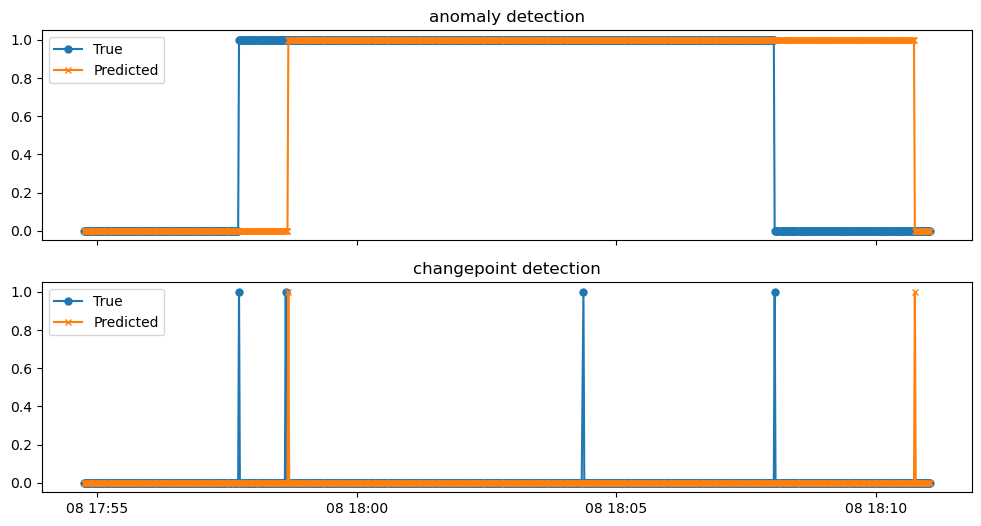

In [8]:
# [donotremove]
plot_results(
    (true_outlier[1], predicted_outlier[1]),
    (true_cp[1], predicted_cp[1]),
)

## Evaluation (metrics calculation)

In [9]:
import pickle

pickle.dump(
    predicted_outlier,
    open(f"../results/results-{model.__class__.__name__}.pkl", "wb"),
)

In [10]:
# =====================================================
# 1. Pobranie lossów z modelu (PyTorch / Keras fallback)
# =====================================================

if hasattr(model, "history"):
    train_losses = model.history.get("train_loss", None)
    val_losses = model.history.get("val_loss", None)

elif hasattr(model, "train_losses"):
    train_losses = model.train_losses
    val_losses = getattr(model, "val_losses", None)

else:
    raise AttributeError("Model has no training history information")

In [11]:
# =====================================================
# 2. Sprawdzenie czy train_losses istnieje
# =====================================================

if train_losses is None or len(train_losses) == 0:
    raise ValueError("train_losses is empty or missing")

In [12]:
# =====================================================
# 3. Epoki
# =====================================================

epochs = range(1, len(train_losses) + 1)

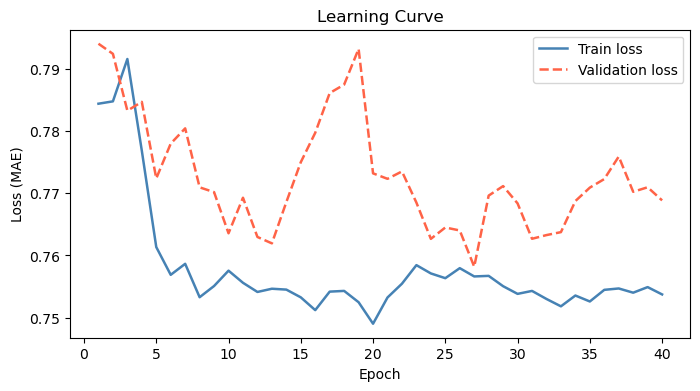

In [13]:
# =====================================================
# 4. Plot
# =====================================================

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    epochs,
    train_losses,
    label="Train loss",
    color="steelblue",
    linewidth=1.8
)

# WALIDACJA JEST OPCJONALNA
if val_losses is not None and len(val_losses) > 0:
    ax.plot(
        epochs,
        val_losses,
        label="Validation loss",
        color="tomato",
        linewidth=1.8,
        linestyle="--"
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (MAE)")
ax.set_title("Learning Curve")
ax.legend()

Zapisano ROC: images/roc_lstm_ae.png


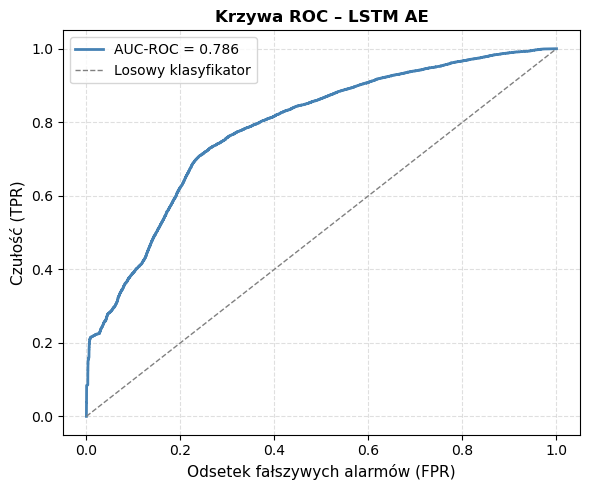

Zapisano PR: images/pr_lstm_ae.png


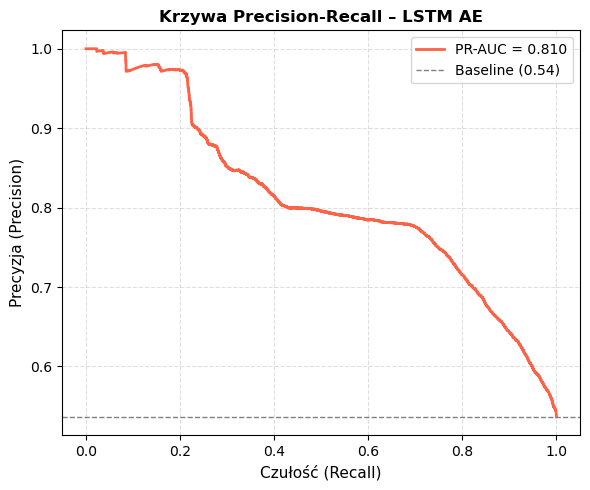


Model:    LSTM AE
AUC-ROC:  0.7864
PR-AUC:   0.8104
MCC:      0.4672  (próg optymalny = 1.4978)

{'auc_roc': 0.7864, 'pr_auc': 0.8104, 'mcc': 0.4672}


In [14]:
# ============================================================
# LSTM AE – krzywe ROC i PR
# ============================================================
from core.plot_roc_pr import plot_roc_pr

metrics = plot_roc_pr(
    scores_list = all_scores,
    labels_list = true_outlier,
    model_name  = 'LSTM AE',
    save_roc    = 'images/roc_lstm_ae.png',
    save_pr     = 'images/pr_lstm_ae.png',
)
print(metrics)

In [15]:
# ============================================================
# LSTM AE – zapis scores/labels do zbiorczego wykresu
# ============================================================
import numpy as np
from pathlib import Path

Path('results').mkdir(exist_ok=True)
np.save('results/scores_lstm_ae.npy',
        np.array(all_scores, dtype=object),
        allow_pickle=True)
np.save('results/labels_lstm_ae.npy',
        np.array(true_outlier, dtype=object),
        allow_pickle=True)
print("OK: LSTM AE zapisany")

OK: LSTM AE zapisany


scores: 23801, labels: 23801


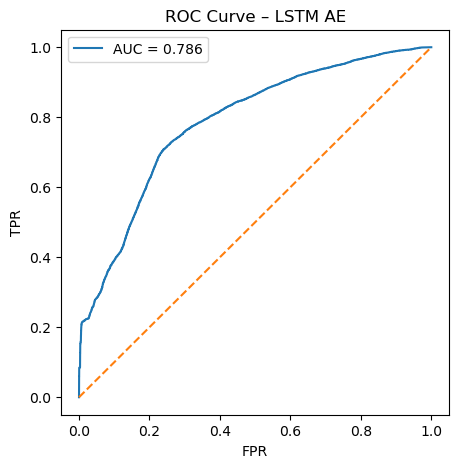

In [16]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

scores_all = np.concatenate([
    s.values if hasattr(s, 'values') else s for s in all_scores
])
labels_all = np.concatenate([
    l.values if hasattr(l, 'values') else l for l in true_outlier
])
print(f"scores: {len(scores_all)}, labels: {len(labels_all)}")

fpr, tpr, _ = roc_curve(labels_all, scores_all)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve – LSTM AE")
plt.legend()
plt.show()

In [17]:
print("Liczba eksperymentów scores:", len(all_scores))
print("Liczba eksperymentów labels:", len(true_outlier))
print()
for i, (s, l) in enumerate(zip(all_scores, true_outlier)):
    print(f"Exp {i}: scores={len(s)}, labels={len(l)}")

Liczba eksperymentów scores: 34
Liczba eksperymentów labels: 34

Exp 0: scores=345, labels=345
Exp 1: scores=927, labels=927
Exp 2: scores=790, labels=790
Exp 3: scores=648, labels=648
Exp 4: scores=523, labels=523
Exp 5: scores=505, labels=505
Exp 6: scores=380, labels=380
Exp 7: scores=737, labels=737
Exp 8: scores=791, labels=791
Exp 9: scores=755, labels=755
Exp 10: scores=747, labels=747
Exp 11: scores=690, labels=690
Exp 12: scores=747, labels=747
Exp 13: scores=744, labels=744
Exp 14: scores=747, labels=747
Exp 15: scores=745, labels=745
Exp 16: scores=746, labels=746
Exp 17: scores=741, labels=741
Exp 18: scores=740, labels=740
Exp 19: scores=740, labels=740
Exp 20: scores=739, labels=739
Exp 21: scores=750, labels=750
Exp 22: scores=675, labels=675
Exp 23: scores=748, labels=748
Exp 24: scores=695, labels=695
Exp 25: scores=754, labels=754
Exp 26: scores=754, labels=754
Exp 27: scores=694, labels=694
Exp 28: scores=744, labels=744
Exp 29: scores=748, labels=748
Exp 30: scores=

Zapisano: images/lc_lstm_ae.png


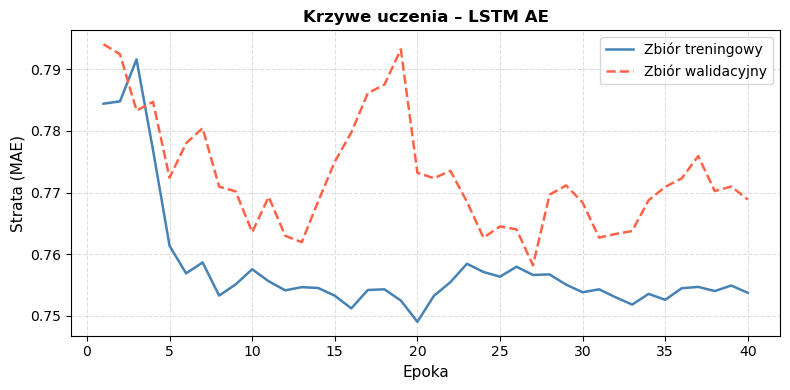

In [18]:
# ============================================================
# LSTM AE – krzywa uczenia
# ============================================================

import os
from core.plot_learning_curve import plot_learning_curve

os.makedirs("images", exist_ok=True)

plot_learning_curve(
    model,
    'LSTM AE',
    save_path='images/lc_lstm_ae.png'
)

### Binary classification (outlier detection) metrics

In [19]:
# [donotremove]
# binary classification metrics calculation
binary = chp_score(true_outlier, predicted_outlier, metric="binary")

False Alarm Rate 12.33 %
Missing Alarm Rate 48.34 %
F1 metric 0.64


### Changepoint detection metrics

In [20]:
# [donotremove]
# average detection delay metric calculation
add = chp_score(
    true_cp,
    predicted_cp,
    metric="average_time",
    window_width="60s",
    anomaly_window_destination="righter",
)

Amount of true anomalies 127
A number of missed CPs = 88
A number of FPs = 91
Average time 0 days 00:00:16.512820


In [21]:
# [donotremove]
# nab metric calculation
nab = chp_score(
    true_cp,
    predicted_cp,
    metric="nab",
    window_width="60s",
    anomaly_window_destination="righter",
)

Standard  -  22.15
LowFP  -  17.75
LowFN  -  25.0
